# 03 — Feature Engineering and Baseline Models

## Purpose

This notebook begins the first stage of forecasting model development.

Using the validated dataset `gold.gold_m5_daily_feature_mart`, this notebook will:

- construct time-series features suitable for forecasting
- create lag and rolling-demand features
- build simple baseline models
- evaluate baseline forecasting performance
- establish reference metrics that future models must beat

Baseline models are essential in production-grade forecasting systems because they provide a minimum performance benchmark.

## Dataset

Source table:

`gold.gold_m5_daily_feature_mart`

Forecast grain:

`(store_id, item_id, date)`

Target variable:

`sales`

Forecast horizon:

**28 days**

## Scope of this notebook

This notebook will include:

- feature engineering
- lag feature creation
- rolling window features
- simple baseline models
- baseline evaluation metrics

This notebook will **not** include:

- MLflow experiment tracking
- advanced machine learning models
- model registration
- deployment workflows

Those steps will come later in the MLOps pipeline.

In [1]:
# Core
import warnings

# Data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# SQL / project imports
from sqlalchemy import text

from app_config.config import settings
from database.database import warehouse_engine

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 200)

print("Libraries and warehouse connection imports loaded successfully.")
print("Configured warehouse DSN present:", bool(settings.WAREHOUSE_DSN or settings.POSTGRES_DSN))

Libraries and warehouse connection imports loaded successfully.
Configured warehouse DSN present: True


# ## Load modeling dataset

We load the modeling dataset from the warehouse table:

`gold.gold_m5_daily_feature_mart`

Because the dataset is large (~2.7M rows), we will **not pull the full dataset immediately**.  
Instead, we will first load a **controlled subset of item-store series** to safely develop and test feature engineering logic.

This keeps the notebook responsive while we build the forecasting pipeline.

Later in the workflow the same logic will be applied to the **full dataset inside production training code**.

In [3]:
subset_query = """
with series_rank as (
    select
        store_id,
        item_id,
        sum(sales) as total_sales
    from gold.gold_m5_daily_feature_mart
    group by store_id, item_id
),
top_series as (
    select
        store_id,
        item_id
    from series_rank
    order by total_sales desc
    limit 20
)
select
    g.id,
    g.item_id,
    g.dept_id,
    g.cat_id,
    g.store_id,
    g.state_id,
    g.d,
    g.date,
    g.wm_yr_wk,
    g.sales,
    g.sell_price,
    g.temperature_2m_max,
    g.temperature_2m_min,
    g.precipitation_sum,
    g.wind_speed_10m_max,
    g.cpi_all_items,
    g.unemployment_rate,
    g.federal_funds_rate,
    g.nonfarm_payrolls,
    g.trends_walmart,
    g.trends_grocery_store,
    g.trends_discount_store,
    g.trends_cleaning_supplies
from gold.gold_m5_daily_feature_mart g
join top_series t
  on g.store_id = t.store_id
 and g.item_id = t.item_id
order by g.store_id, g.item_id, g.date
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(subset_query))
    model_df = pd.DataFrame(result.fetchall(), columns=result.keys())

model_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,date,wm_yr_wk,sales,sell_price,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,cpi_all_items,unemployment_rate,federal_funds_rate,nonfarm_payrolls,trends_walmart,trends_grocery_store,trends_discount_store,trends_cleaning_supplies
0,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1824,2016-01-26,11552,37,1,16.5,2.5,0.0,6.0,237,4,0,143210,49,46,57,62
1,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1825,2016-01-27,11552,35,1,16.3,5.7,0.0,7.2,237,4,0,143210,51,46,55,73
2,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1826,2016-01-28,11552,38,1,15.5,3.3,0.0,11.2,237,4,0,143210,51,46,49,68
3,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1827,2016-01-29,11552,39,1,17.2,7.9,0.0,6.2,237,4,0,143210,52,46,57,76
4,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1828,2016-01-30,11601,65,1,11.8,9.5,8.2,9.2,237,4,0,143210,68,57,83,45


In [4]:
model_df.shape

(1800, 23)

### Controlled modeling subset

The current working dataset contains:

- **20 item-store series**
- **1,800 rows**
- **23 columns**

This subset is intentionally small enough for fast, reliable notebook iteration.

At this stage, the goal is to validate:

- feature engineering logic
- lag construction
- rolling-window calculations
- baseline evaluation workflow

Only after this logic is confirmed will it be applied to the full dataset in a scalable way.

In [5]:
model_df["date"] = pd.to_datetime(model_df["date"])

model_df = model_df.sort_values(["store_id", "item_id", "date"]).reset_index(drop=True)

model_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,date,wm_yr_wk,sales,sell_price,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,cpi_all_items,unemployment_rate,federal_funds_rate,nonfarm_payrolls,trends_walmart,trends_grocery_store,trends_discount_store,trends_cleaning_supplies
0,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1824,2016-01-26,11552,37,1,16.5,2.5,0.0,6.0,237,4,0,143210,49,46,57,62
1,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1825,2016-01-27,11552,35,1,16.3,5.7,0.0,7.2,237,4,0,143210,51,46,55,73
2,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1826,2016-01-28,11552,38,1,15.5,3.3,0.0,11.2,237,4,0,143210,51,46,49,68
3,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1827,2016-01-29,11552,39,1,17.2,7.9,0.0,6.2,237,4,0,143210,52,46,57,76
4,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1828,2016-01-30,11601,65,1,11.8,9.5,8.2,9.2,237,4,0,143210,68,57,83,45


In [6]:
model_df[["store_id", "item_id", "date"]].dtypes

store_id            object
item_id             object
date        datetime64[ns]
dtype: object

In [7]:
model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["day_of_month"] = model_df["date"].dt.day
model_df["week_of_year"] = model_df["date"].dt.isocalendar().week.astype(int)
model_df["month"] = model_df["date"].dt.month

model_df[["date", "day_of_week", "day_of_month", "week_of_year", "month"]].head()

,date,day_of_week,day_of_month,week_of_year,month
0,2016-01-26,1,26,4,1
1,2016-01-27,2,27,4,1
2,2016-01-28,3,28,4,1
3,2016-01-29,4,29,4,1
4,2016-01-30,5,30,4,1


### Calendar features added

The first set of time-based features has now been created from the `date` column:

- `day_of_week`
- `day_of_month`
- `week_of_year`
- `month`

These are simple but important forecasting features because retail demand often varies by weekday, week pattern, and month-related seasonality.

Next, we will begin creating **historical demand features**, starting with lag-based features.

In [8]:
group_cols = ["store_id", "item_id"]

model_df["lag_1"] = model_df.groupby(group_cols)["sales"].shift(1)
model_df["lag_7"] = model_df.groupby(group_cols)["sales"].shift(7)
model_df["lag_28"] = model_df.groupby(group_cols)["sales"].shift(28)

model_df[["store_id", "item_id", "date", "sales", "lag_1", "lag_7", "lag_28"]].head(35)

,store_id,item_id,date,sales,lag_1,lag_7,lag_28
0,CA_1,FOODS_3_090,2016-01-26,37,NaN,NaN,NaN
1,CA_1,FOODS_3_090,2016-01-27,35,37.0,NaN,NaN
2,CA_1,FOODS_3_090,2016-01-28,38,35.0,NaN,NaN
3,CA_1,FOODS_3_090,2016-01-29,39,38.0,NaN,NaN
4,CA_1,FOODS_3_090,2016-01-30,65,39.0,NaN,NaN
5,CA_1,FOODS_3_090,2016-01-31,39,65.0,NaN,NaN
6,CA_1,FOODS_3_090,2016-02-01,51,39.0,NaN,NaN
7,CA_1,FOODS_3_090,2016-02-02,31,51.0,37.0,NaN
8,CA_1,FOODS_3_090,2016-02-03,48,31.0,35.0,NaN
9,CA_1,FOODS_3_090,2016-02-04,50,48.0,38.0,NaN


### Lag features

Lag features capture **historical demand signals**, which are the most important predictors in retail forecasting.

The following lag features were created:

- `lag_1` → demand from the previous day
- `lag_7` → demand from the same weekday in the previous week
- `lag_28` → demand from four weeks prior (monthly seasonal signal)

These features allow forecasting models to learn:

- short-term demand persistence
- weekly seasonality
- medium-term demand patterns

The first observations of each time series naturally contain `NaN` values because historical data does not exist for those lags.

In [9]:
model_df["rolling_mean_7"] = (
    model_df.groupby(["store_id", "item_id"])["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

model_df["rolling_mean_28"] = (
    model_df.groupby(["store_id", "item_id"])["sales"]
    .shift(1)
    .rolling(28)
    .mean()
)

model_df[
    [
        "store_id",
        "item_id",
        "date",
        "sales",
        "rolling_mean_7",
        "rolling_mean_28",
    ]
].head(40)

,store_id,item_id,date,sales,rolling_mean_7,rolling_mean_28
0,CA_1,FOODS_3_090,2016-01-26,37,NaN,NaN
1,CA_1,FOODS_3_090,2016-01-27,35,NaN,NaN
2,CA_1,FOODS_3_090,2016-01-28,38,NaN,NaN
3,CA_1,FOODS_3_090,2016-01-29,39,NaN,NaN
4,CA_1,FOODS_3_090,2016-01-30,65,NaN,NaN
5,CA_1,FOODS_3_090,2016-01-31,39,NaN,NaN
6,CA_1,FOODS_3_090,2016-02-01,51,NaN,NaN
7,CA_1,FOODS_3_090,2016-02-02,31,43.428571,NaN
8,CA_1,FOODS_3_090,2016-02-03,48,42.571429,NaN
9,CA_1,FOODS_3_090,2016-02-04,50,44.428571,NaN


### Rolling mean features

Rolling mean features smooth short-term volatility and provide a stable view of recent demand history.

The following features were created:

- `rolling_mean_7` → average demand over the previous 7 days
- `rolling_mean_28` → average demand over the previous 28 days

Important design rule:

- both rolling features use `.shift(1)` before the rolling calculation
- this ensures the current day’s sales are **not included**
- therefore the features remain **leakage-safe**

These features are especially useful in sparse retail demand data because they summarize recent behavior better than a single lag alone.

In [10]:
feature_cols = [
    "sales",
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "lag_1",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
]

feature_view_df = model_df[
    ["store_id", "item_id", "date"] + feature_cols
].copy()

feature_view_df.head(35)

,store_id,item_id,date,sales,day_of_week,day_of_month,week_of_year,month,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28
0,CA_1,FOODS_3_090,2016-01-26,37,1,26,4,1,NaN,NaN,NaN,NaN,NaN
1,CA_1,FOODS_3_090,2016-01-27,35,2,27,4,1,37.0,NaN,NaN,NaN,NaN
2,CA_1,FOODS_3_090,2016-01-28,38,3,28,4,1,35.0,NaN,NaN,NaN,NaN
3,CA_1,FOODS_3_090,2016-01-29,39,4,29,4,1,38.0,NaN,NaN,NaN,NaN
4,CA_1,FOODS_3_090,2016-01-30,65,5,30,4,1,39.0,NaN,NaN,NaN,NaN
5,CA_1,FOODS_3_090,2016-01-31,39,6,31,4,1,65.0,NaN,NaN,NaN,NaN
6,CA_1,FOODS_3_090,2016-02-01,51,0,1,5,2,39.0,NaN,NaN,NaN,NaN
7,CA_1,FOODS_3_090,2016-02-02,31,1,2,5,2,51.0,37.0,NaN,43.428571,NaN
8,CA_1,FOODS_3_090,2016-02-03,48,2,3,5,2,31.0,35.0,NaN,42.571429,NaN
9,CA_1,FOODS_3_090,2016-02-04,50,3,4,5,2,48.0,38.0,NaN,44.428571,NaN


In [11]:
baseline_df = feature_view_df.dropna().copy()

baseline_df.shape

(1240, 13)

### Training dataset after lag feature creation

After removing rows with missing lag and rolling-window values, the modeling dataset now contains:

- **1,240 rows**
- **13 columns**

These rows represent observations where all historical features are available.

The earlier rows of each time series were removed because lag and rolling features require historical observations to be computed.

This cleaned dataset will now be used to construct **baseline forecasting models**.

In [12]:
split_date = baseline_df["date"].max() - pd.Timedelta(days=27)

train_df = baseline_df[baseline_df["date"] < split_date].copy()
test_df = baseline_df[baseline_df["date"] >= split_date].copy()

print("Split date:", split_date.date())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Split date: 2016-03-28
Train shape: (680, 13)
Test shape: (560, 13)


### Train / Test split

A time-based split is used to simulate real forecasting conditions.

Split date: **2016-03-28**

- **Training set:** 680 rows  
- **Test set:** 560 rows  

All rows before the split date are used for training, while the final **28 days** are held out for evaluation.

This approach prevents information leakage and mimics how the model would behave in a real forecasting scenario where future observations are unknown at training time.

In [14]:
test_df.head()

,store_id,item_id,date,sales,day_of_week,day_of_month,week_of_year,month,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,pred_naive_lag_1
62,CA_1,FOODS_3_090,2016-03-28,25,0,28,13,3,112.0,40.0,42.0,61.000000,54.035714,112.0
63,CA_1,FOODS_3_090,2016-03-29,47,1,29,13,3,25.0,36.0,41.0,58.857143,53.428571,25.0
64,CA_1,FOODS_3_090,2016-03-30,23,2,30,13,3,47.0,29.0,53.0,60.428571,53.642857,47.0
65,CA_1,FOODS_3_090,2016-03-31,21,3,31,13,3,23.0,48.0,46.0,59.571429,52.571429,23.0
66,CA_1,FOODS_3_090,2016-04-01,72,4,1,13,4,21.0,60.0,67.0,55.714286,51.678571,21.0


In [13]:
test_df["pred_naive_lag_1"] = test_df["lag_1"]

test_df[["store_id", "item_id", "date", "sales", "pred_naive_lag_1"]].head()

,store_id,item_id,date,sales,pred_naive_lag_1
62,CA_1,FOODS_3_090,2016-03-28,25,112.0
63,CA_1,FOODS_3_090,2016-03-29,47,25.0
64,CA_1,FOODS_3_090,2016-03-30,23,47.0
65,CA_1,FOODS_3_090,2016-03-31,21,23.0
66,CA_1,FOODS_3_090,2016-04-01,72,21.0


In [15]:
import numpy as np

wmape = np.sum(np.abs(test_df["sales"] - test_df["pred_naive_lag_1"])) / np.sum(test_df["sales"])

print("Naive lag-1 WMAPE:", round(wmape, 4))

Naive lag-1 WMAPE: 0.2893


### Baseline model: Naive lag-1 forecast

The first benchmark model uses a **naive lag-1 strategy**, where the prediction for each day is simply the demand from the previous day.

Prediction rule:

prediction(t) = sales(t-1)

Evaluation result:

Weighted Mean Absolute Percentage Error (**WMAPE) = 0.2893**


This baseline is important because it establishes the **minimum performance threshold** that any future model must outperform.

In demand forecasting, naive models are often surprisingly strong because demand tends to exhibit short-term persistence.

All future models (moving average, gradient boosting, etc.) must achieve a **lower WMAPE than this baseline** to justify their complexity.

In [16]:
test_df["pred_naive_lag_7"] = test_df["lag_7"]

wmape_lag7 = np.sum(np.abs(test_df["sales"] - test_df["pred_naive_lag_7"])) / np.sum(test_df["sales"])

print("Seasonal naive (lag-7) WMAPE:", round(wmape_lag7, 4))

Seasonal naive (lag-7) WMAPE: 0.2423


### Baseline model: Seasonal naive (lag-7)

The second baseline model uses a **seasonal naive strategy** based on weekly seasonality.

Prediction rule:

prediction(t) = sales(t-7)

This assumes that demand on a given weekday will be similar to the demand on the same weekday in the previous week.

Evaluation result:

**WMAPE = 0.2423**

This result improves over the lag-1 baseline:

- Naive lag-1 WMAPE: **0.2893**
- Seasonal naive lag-7 WMAPE: **0.2423**

This confirms that **weekly seasonality is a strong signal** in the dataset.

Future forecasting models must outperform **WMAPE = 0.2423** to demonstrate real improvement over simple seasonal persistence.

In [17]:
test_df["pred_rolling_7"] = test_df["rolling_mean_7"]

wmape_roll7 = np.sum(np.abs(test_df["sales"] - test_df["pred_rolling_7"])) / np.sum(test_df["sales"])

print("Rolling mean (7-day) WMAPE:", round(wmape_roll7, 4))

Rolling mean (7-day) WMAPE: 0.2621


### Baseline model: Rolling 7-day mean

The third baseline uses the **7-day rolling mean of past demand**.

Prediction rule:

prediction(t) = mean(sales(t-7) … sales(t-1))

Evaluation result:

**WMAPE = 0.2621**

Comparison with previous baselines:

| Model | WMAPE |
|------|------|
| Naive lag-1 | 0.2893 |
| Seasonal naive lag-7 | **0.2423** |
| Rolling mean (7-day) | 0.2621 |

The **seasonal naive (lag-7)** baseline currently performs best.

This indicates that **weekly seasonality is the dominant signal** in the data, and future models must beat **WMAPE = 0.2423** to demonstrate improvement.

In [18]:
feature_columns = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "lag_1",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
]

X_train = train_df[feature_columns]
y_train = train_df["sales"]

X_test = test_df[feature_columns]
y_test = test_df["sales"]

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Training features shape: (680, 9)
Test features shape: (560, 9)


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained.")

Random Forest model trained.


In [20]:
test_df["pred_rf"] = rf_model.predict(X_test)

wmape_rf = np.sum(np.abs(test_df["sales"] - test_df["pred_rf"])) / np.sum(test_df["sales"])

print("Random Forest WMAPE:", round(wmape_rf, 4))

Random Forest WMAPE: 0.2195


### First machine learning model: Random Forest

A Random Forest regression model was trained using the engineered time-series features.

Model features:

- calendar features
- lagged demand signals
- rolling demand averages

Evaluation result:

**Random Forest WMAPE = 0.2195**

Baseline comparison:

| Model | WMAPE |
|------|------|
| Naive lag-1 | 0.2893 |
| Seasonal naive lag-7 | 0.2423 |
| Rolling mean (7-day) | 0.2621 |
| Random Forest | **0.2195** |

The Random Forest model **outperforms all baseline models**, demonstrating that combining lag features, calendar features, and rolling demand statistics improves forecasting performance.

This confirms that the engineered features provide meaningful predictive signal.

In [21]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
4,lag_1,0.221737
5,lag_7,0.206844
6,lag_28,0.204514
8,rolling_mean_28,0.165133
7,rolling_mean_7,0.068953
0,day_of_week,0.067736
1,day_of_month,0.033914
2,week_of_year,0.029693
3,month,0.001475


### Feature importance analysis

The Random Forest model highlights which features contribute most to forecasting accuracy.

Key observations:

Most important predictors:

- `lag_1`
- `lag_7`
- `lag_28`
- `rolling_mean_28`

These results confirm a well-known principle in retail demand forecasting:

**historical demand is the strongest predictor of future demand.**

Calendar features such as:

- `day_of_week`
- `day_of_month`
- `week_of_year`

still contribute useful signal but are less influential than lagged demand.

The `month` feature has minimal importance because the dataset covers only a short time window.

This analysis confirms that the **feature engineering strategy is aligned with real-world demand forecasting patterns**.

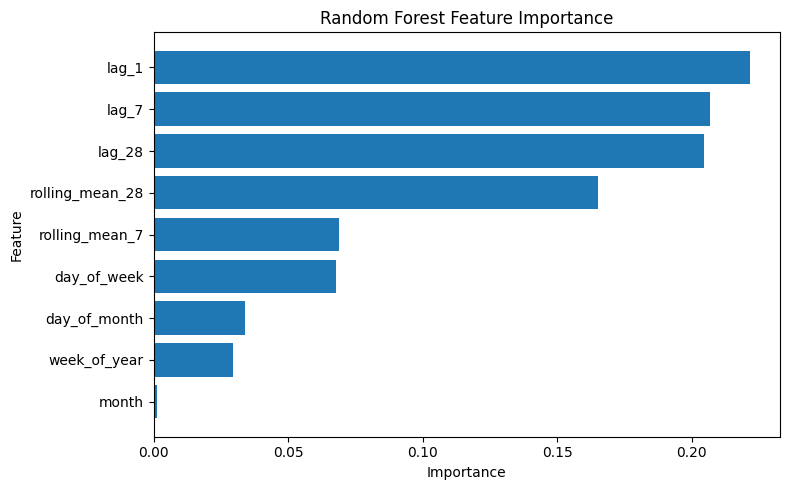

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Summary of modeling results

This notebook established the first forecasting workflow and baseline machine learning model.

Key results:

Baseline performance:

- Naive lag-1 → WMAPE = 0.2893
- Seasonal naive lag-7 → WMAPE = 0.2423
- Rolling mean (7-day) → WMAPE = 0.2621

Machine learning model:

- Random Forest → WMAPE = **0.2195**

The Random Forest model successfully improves upon the best baseline model.

This demonstrates that combining:

- lag features
- rolling demand statistics
- calendar features

can produce better forecasts than simple persistence models.

These results validate the feature engineering pipeline and establish a strong starting point for more advanced models.